#**K-Means Clustering**

**Use the Iris Dataset, which is built into Scikit-learn.**

**Load the dataset**

In [3]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.data.copy()
df['species'] = iris.target
df['species_name'] = df['species'].map(dict(enumerate(iris.target_names)))



**Explore the dataset using Pandas.**

In [4]:

print("First 5 rows:\n", df.head())
print("\nShape:", df.shape)

print("\nInfo:")
df.info()

print("\nDescribe:\n", df.describe())

print("\nSpecies distribution:\n", df['species_name'].value_counts())

print("\nMissing values per column:\n", df.isnull().sum())


First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Shape: (150, 6)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-nu

**Apply K-Means clustering.**
**Use the Elbow Method to determine the optimal number of clusters.**

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


X = iris.data.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), inertias, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_method.png", dpi=150)
plt.close()
print("Saved elbow_method.png")

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster counts:\n", df['cluster'].value_counts())


Saved elbow_method.png

Cluster counts:
 cluster
0    53
1    50
2    47
Name: count, dtype: int64


**Visualize the clusters using a scatter plot.**

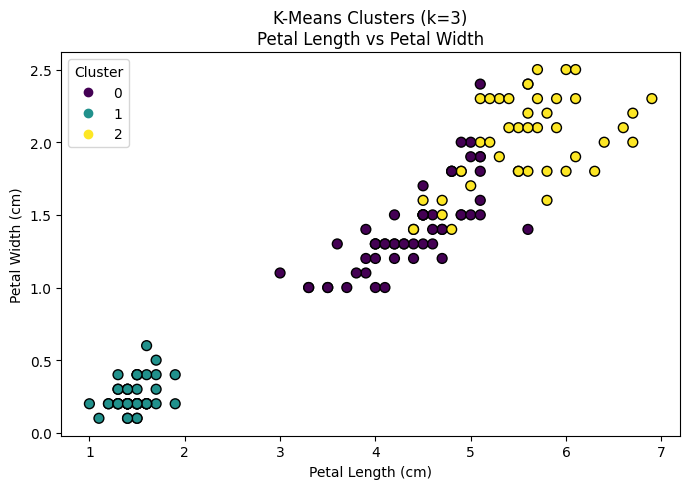

In [10]:

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    df['petal length (cm)'], df['petal width (cm)'],
    c=df['cluster'], cmap='viridis', edgecolor='k', s=50
)
plt.title(f"K-Means Clusters (k={optimal_k})\nPetal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150)
plt.show()

In [11]:

print("Saved kmeans_clusters.png")

crosstab = pd.crosstab(df['species_name'], df['cluster'])
print("\nCluster vs True Species Crosstab:\n", crosstab)


Saved kmeans_clusters.png

Cluster vs True Species Crosstab:
 cluster        0   1   2
species_name            
setosa         0  50   0
versicolor    39   0  11
virginica     14   0  36
